# Multivariate anomaly detection by principal-component analysis
### Detecting compound climate anomalies from several time series at once

This notebook implements and demonstrates the **multiple-time-series anomaly
detection** described in

> N. Laptev, S. Amizadeh, I. Flint, *"Generic and Scalable Framework for
> Automated Time-series Anomaly Detection"* (**EGADS**), KDD 2015,
> DOI 10.1145/2783258.2788611.

EGADS detects three kinds of anomaly (paper Section 3): **(a) outliers**,
**(b) change points**, and **(c) anomalous time-series** — a series whose
behaviour differs from a population of peers. Class (c), *Detecting Anomalous
Time-series* (Section 3.3), is the multivariate one:

> *"…clustering the time-series into a set of clusters C based on various
> time-series features … After clustering we perform intra or inter-cluster
> time-series anomaly detection by measuring the deviation … among the cluster
> centroids and the time-series (i)."*

We implement two complementary **principal-component ("PC")** detectors and show
where each one wins:

| Module | Method | Paper grounding | Detects |
|---|---|---|---|
| `pca_subspace.py` | PCA **normal / residual subspace**: Hotelling **T²** (excursion along the coupled modes) + **SPE / Q-statistic** (correlation-structure break) | Lakhina, Crovella & Diot, *Diagnosing Network-Wide Traffic Anomalies*, SIGCOMM 2004; Jackson & Mudholkar, Technometrics 1979; EGADS §4.1 thresholds | **co-exceedance / level** anomalies — multiple drivers excited together |
| `egads_features.py` + `egads_pc_cluster.py` | EGADS **Table-1 features → PCA → k-means → centroid deviation** | EGADS §3.3 + ref [29] (Wang–Smith-Miles–Hyndman) | **structural / regime** anomalies — series with unusual dynamics |

Both fit on the training span only and threshold with the EGADS §4.1 rules
(parametric *K·σ* / three-sigma, and non-parametric density). The demonstration
data are the coupled ENSO climate indices (Niño-SST, SOI, PDO) with official
**ONI El Niño / La Niña episodes** as ground truth, and a **daily sea-surface
temperature record with labelled marine heat waves (MHW)**.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)

import extra_data as ed
from pca_subspace import PCASubspaceDetector
from egads_detector import AnomalousSeriesDetector, evaluate
from egads_features import FEATURE_NAMES

# Okabe-Ito colourblind-safe categorical palette, assigned in fixed order.
OI = ["#0072B2","#E69F00","#009E73","#D55E00","#CC79A7","#56B4E9","#F0E442","#000000"]
plt.rcParams.update({
    "figure.dpi":120, "figure.figsize":(10,3.2), "axes.grid":True,
    "grid.alpha":0.25, "axes.spines.top":False, "axes.spines.right":False,
    "axes.prop_cycle": plt.cycler(color=OI), "font.size":10, "legend.frameon":False,
})
EVENT_C, FLAG_C, LIMIT_C = "#D55E00", "#0072B2", "#666666"

def shade(ax, dates, mask, color=EVENT_C, alpha=0.18, label=None):
    '''Shade contiguous True runs of `mask` along the date axis.'''
    mask = np.asarray(mask, bool); d = pd.to_datetime(pd.Series(dates)).values
    i = 0; first = True
    while i < len(mask):
        if mask[i]:
            j = i
            while j+1 < len(mask) and mask[j+1]: j += 1
            ax.axvspan(d[i], d[j], color=color, alpha=alpha,
                       lw=0, label=(label if first else None)); first=False
            i = j+1
        else: i += 1
print("ready")

ready


## Part A — Compound ENSO co-exceedance (PCA subspace T² / SPE)

The El Niño–Southern Oscillation couples three monthly indices: the
Niño-region **SST** anomaly, the **Southern Oscillation Index (SOI)** and the
**Pacific Decadal Oscillation (PDO)**. A *compound* event is a month in which
all three sit in their alarming tail simultaneously (SST high, SOI low, PDO
high) — the rare, high-impact anomaly. `retrieve_data.prepare_compound` builds
the leak-free, common-span anomaly matrix; `extra_data` attaches the official
NOAA/CPC **ONI episode** labels on the same grid.

[compound sst+soi+pdo] 720 months 1951-01..2010-12; train [0,581); compound base rate 0.039 (28 months)
[enso-labeled] 720 months, channels ['sst', 'soi', 'pdo']; ONI warm=190 cold=180 any=370; compound=28


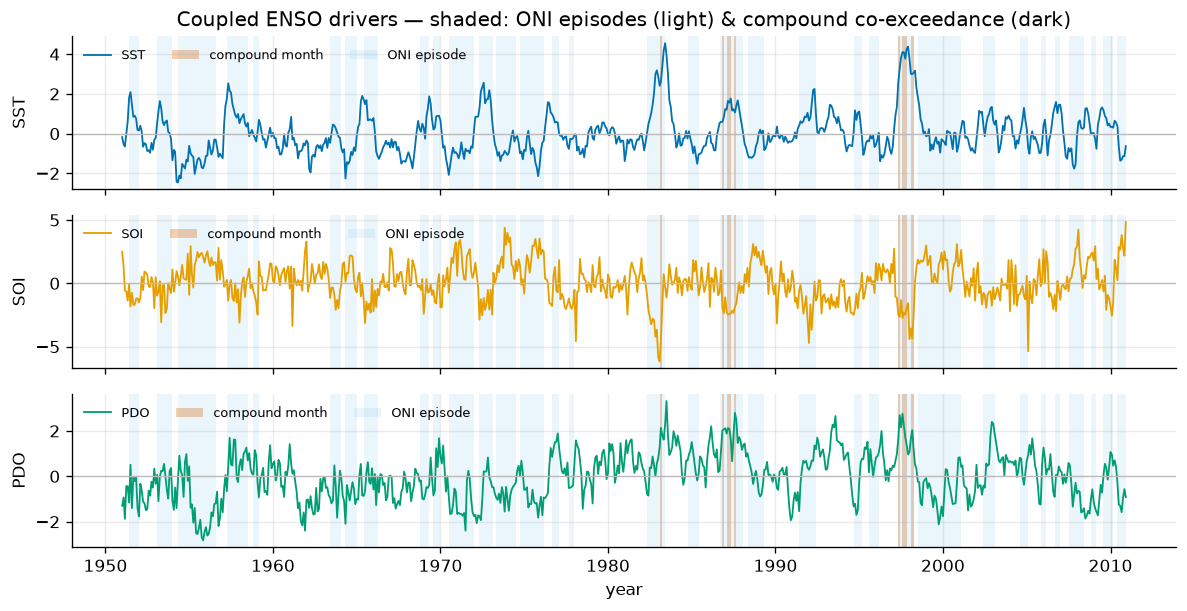

In [2]:
D = ed.build_enso_labeled(names=("sst","soi","pdo"), verbose=True)
dates, X, chans = D["dates"], D["X"], D["channel_names"]
fig, axes = plt.subplots(3,1, figsize=(10,5.2), sharex=True)
for ax, c, name in zip(axes, range(3), chans):
    ax.plot(dates, X[:,c], color=OI[c], lw=1.1, label=name.upper())
    shade(ax, dates, D["label_compound"], EVENT_C, 0.30, "compound month")
    shade(ax, dates, D["label_enso"], "#56B4E9", 0.12, "ONI episode")
    ax.axhline(0, color="#bbbbbb", lw=0.8); ax.legend(loc="upper left", ncol=3, fontsize=8)
    ax.set_ylabel(name.upper())
axes[0].set_title("Coupled ENSO drivers — shaded: ONI episodes (light) & compound co-exceedance (dark)")
axes[-1].set_xlabel("year"); plt.tight_layout(); plt.show()

### The PCA normal model and the coupled ENSO mode

Fit `PCASubspaceDetector` on the training span. With three channels the compound
signal is a large excursion **along the leading principal component** (the
coupled ENSO mode), so we take a one-dimensional normal subspace (`k=1`): T²
measures that excursion, SPE the leftover correlation-structure break. The PC1
loadings recover the physical sign pattern SST(+) / SOI(−) / PDO(+).

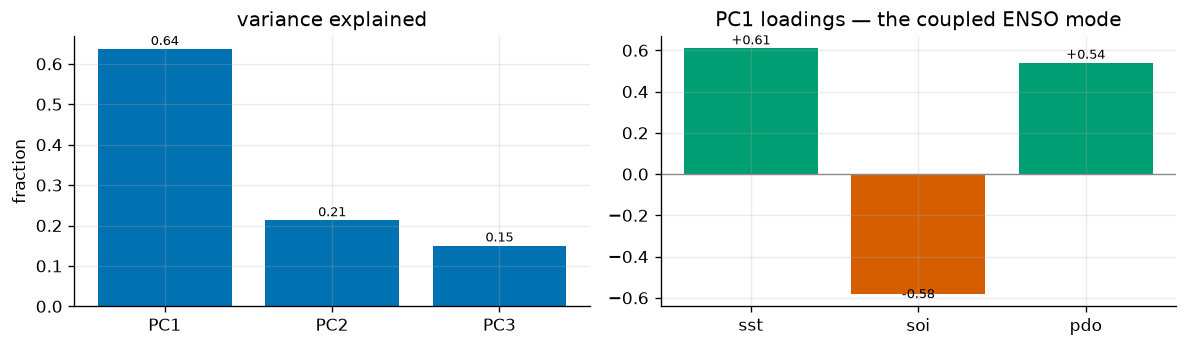

normal-subspace dim k=1;  T² limit=5.44;  SPE(Q) limit=4.35


In [3]:
det = PCASubspaceDetector(k=1, alpha=0.02).fit(X, n_train=D["n_train"])
evr = det.explained_variance_ratio()
pc1 = det.components_[:,0]
fig, (a0,a1) = plt.subplots(1,2, figsize=(10,3.0))
a0.bar(range(len(evr)), evr, color=OI[0]); a0.set_xticks(range(len(evr)))
a0.set_xticklabels([f"PC{i+1}" for i in range(len(evr))])
a0.set_title("variance explained"); a0.set_ylabel("fraction")
for i,v in enumerate(evr): a0.text(i, v+0.01, f"{v:.2f}", ha="center", fontsize=8)
cols = [OI[2] if v>=0 else OI[3] for v in pc1]
a1.bar(chans, pc1, color=cols); a1.axhline(0, color="#888", lw=0.8)
a1.set_title("PC1 loadings — the coupled ENSO mode")
for i,v in enumerate(pc1): a1.text(i, v+0.02*np.sign(v), f"{v:+.2f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()
print(f"normal-subspace dim k={det.k_};  T² limit={det.t2_limit_:.2f};  SPE(Q) limit={det.spe_limit_:.2f}")

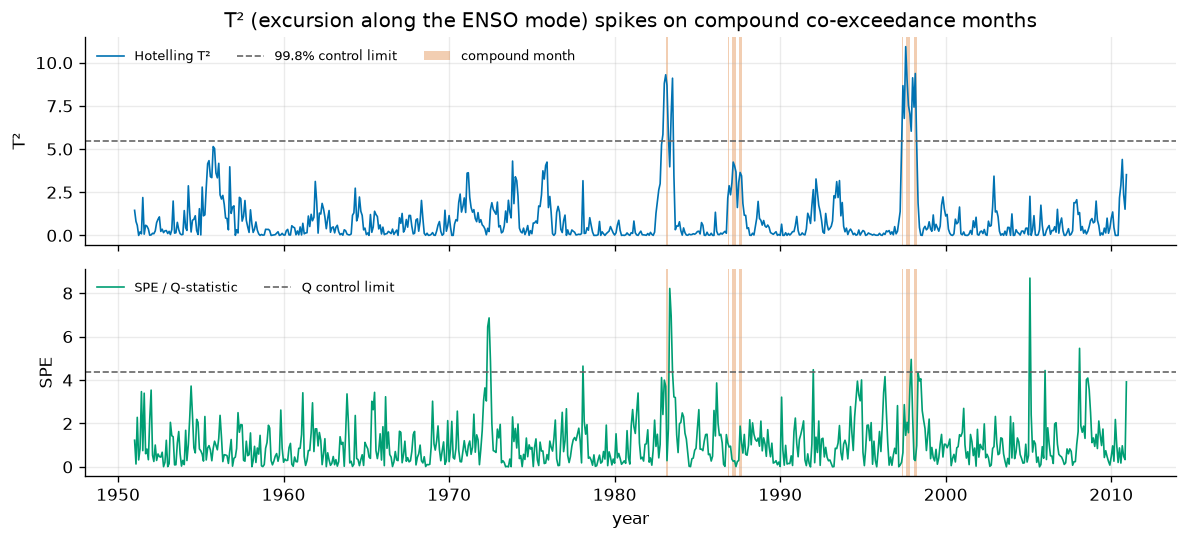

In [4]:
s = det.score(X)
fig, (a0,a1) = plt.subplots(2,1, figsize=(10,4.6), sharex=True)
a0.plot(dates, s["t2"], color=FLAG_C, lw=1.0, label="Hotelling T²")
a0.axhline(det.t2_limit_, color=LIMIT_C, ls="--", lw=1.0, label="99.8% control limit")
shade(a0, dates, D["label_compound"], EVENT_C, 0.30, "compound month")
a0.legend(loc="upper left", ncol=3, fontsize=8); a0.set_ylabel("T²")
a0.set_title("T² (excursion along the ENSO mode) spikes on compound co-exceedance months")
a1.plot(dates, s["spe"], color=OI[2], lw=1.0, label="SPE / Q-statistic")
a1.axhline(det.spe_limit_, color=LIMIT_C, ls="--", lw=1.0, label="Q control limit")
shade(a1, dates, D["label_compound"], EVENT_C, 0.30)
a1.legend(loc="upper left", ncol=2, fontsize=8); a1.set_ylabel("SPE"); a1.set_xlabel("year")
plt.tight_layout(); plt.show()

### How well does T² rank the anomalies? (threshold-free)

Because the detector is unsupervised, we first score it threshold-free with ROC
and precision–recall curves against the labels, then report the operating point
of each EGADS §4.1 threshold rule.

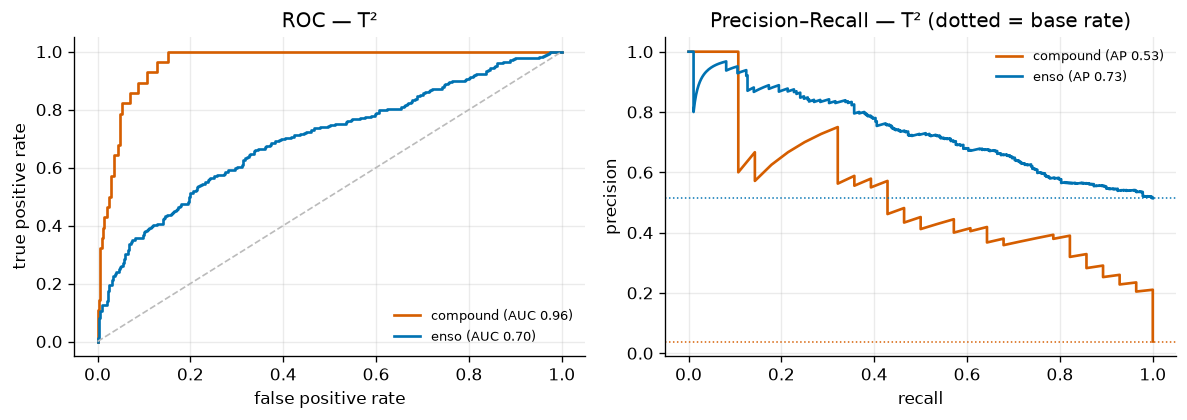

   label  base_rate  ROC_AUC  avg_precision
compound   0.038889 0.963512       0.526901
    enso   0.513889 0.701143       0.733522


In [5]:
fig, (a0,a1) = plt.subplots(1,2, figsize=(10,3.6))
rows=[]
for lab, col in [("label_compound",OI[3]), ("label_enso",OI[0])]:
    y=D[lab]
    fpr,tpr,_=roc_curve(y, s["t2"]); pr,rc,_=precision_recall_curve(y, s["t2"])
    auc=roc_auc_score(y,s["t2"]); ap=average_precision_score(y,s["t2"])
    a0.plot(fpr,tpr,color=col,lw=1.6,label=f"{lab[6:]} (AUC {auc:.2f})")
    a1.plot(rc,pr,color=col,lw=1.6,label=f"{lab[6:]} (AP {ap:.2f})")
    a1.axhline(y.mean(), color=col, ls=":", lw=0.9)
    rows.append((lab[6:], y.mean(), auc, ap))
a0.plot([0,1],[0,1],color="#bbb",ls="--",lw=1); a0.set(xlabel="false positive rate",ylabel="true positive rate",title="ROC — T²")
a0.legend(fontsize=8); a1.set(xlabel="recall",ylabel="precision",title="Precision–Recall — T² (dotted = base rate)")
a1.legend(fontsize=8); plt.tight_layout(); plt.show()
print(pd.DataFrame(rows, columns=["label","base_rate","ROC_AUC","avg_precision"]).to_string(index=False))

In [6]:
# EGADS Section 4.1 threshold rules at their operating points (full span).
rec=[]
for rule in ("limit","ksigma","density"):
    fl=det.predict(X, which="t2", rule=rule)
    m=evaluate(fl, D["label_compound"])
    rec.append(("T² · "+rule, m["precision"],m["recall"],m["f1"],m["n_pred"],m["n_true"]))
print("Compound co-exceedance detection (base rate {:.3f}):".format(D["label_compound"].mean()))
print(pd.DataFrame(rec, columns=["detector·rule","precision","recall","F1","n_pred","n_true"]).round(3).to_string(index=False))

Compound co-exceedance detection (base rate 0.039):
detector·rule  precision  recall    F1  n_pred  n_true
   T² · limit      0.588   0.357 0.444      17      28
  T² · ksigma      0.588   0.357 0.444      17      28
 T² · density      0.600   0.321 0.419      15      28


## Part B — EGADS §3.3 anomalous-series feature clustering

This is the method the EGADS paper describes literally: characterise each series
with the **Table-1 features** (`egads_features.py` — trend & seasonality
strength, spectral entropy, autocorrelation, Teräsvirta nonlinearity, skewness,
kurtosis, Hurst, Lyapunov), reduce to **principal-component space**, **cluster**
(k-means), and score each series by its **deviation from the cluster centroid**
(`egads_pc_cluster.py`).

We apply it with the standard *bag-of-windows* reduction: each sliding 36-month
window over the three channels is one member of the population, its feature
vector concatenating all channels. The detector flags windows whose **joint
dynamics** are unusual relative to the rest of the record.

windows=685  features/window=33  clusters k=2  PC-variance kept=0.91  flagged windows=83


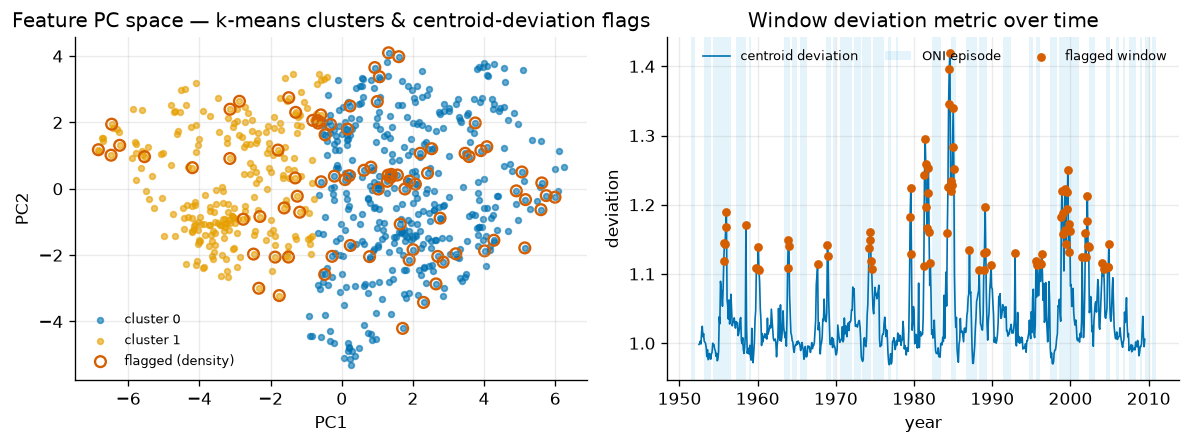

In [7]:
fdet = AnomalousSeriesDetector(win=36, step=1, period=12, rule="density",
        expand="cover", model_kwargs=dict(n_components=0.9, inter_cluster=True,
        lof_neighbors=25, lof_contamination=0.12))
fres = fdet.fit_predict(X, channel_names=chans)
mdl = fres.model
pcs = mdl.pcs_; labels = mdl.kmeans_.predict(pcs)
flags_w, _ = mdl.flag_density()
print(f"windows={len(fres.windows)}  features/window={fres.feature_matrix.shape[1]}  "
      f"clusters k={mdl.k_used_}  PC-variance kept={mdl.explained_variance().sum():.2f}  "
      f"flagged windows={int(flags_w.sum())}")

fig, (a0,a1) = plt.subplots(1,2, figsize=(10,3.8))
for c in range(mdl.k_used_):
    sel = labels==c
    a0.scatter(pcs[sel,0], pcs[sel,1], s=12, color=OI[c], alpha=0.6, label=f"cluster {c}")
a0.scatter(pcs[flags_w,0], pcs[flags_w,1], s=42, facecolors="none",
           edgecolors=EVENT_C, lw=1.4, label="flagged (density)")
a0.set(xlabel="PC1", ylabel="PC2", title="Feature PC space — k-means clusters & centroid-deviation flags")
a0.legend(fontsize=8)
centers = np.array([fres.windows[w][1] for w in range(len(fres.windows))])
a1.plot(dates[centers], fres.window_scores, color=OI[0], lw=1.0, label="centroid deviation")
shade(a1, dates, D["label_enso"], "#56B4E9", 0.15, "ONI episode")
wf = np.zeros(len(dates), bool)
for (st,ct,en),fl in zip(fres.windows, flags_w):
    if fl: wf[ct]=True
a1.scatter(dates[wf], fres.window_scores[[i for i,(st,ct,en) in enumerate(fres.windows) if wf[ct]]],
           color=EVENT_C, s=18, zorder=5, label="flagged window")
a1.set(xlabel="year", ylabel="deviation", title="Window deviation metric over time")
a1.legend(fontsize=8, ncol=3); plt.tight_layout(); plt.show()

**Reading this honestly.** The Table-1 features are deliberately *shape /
dynamics* descriptors and are largely **level-invariant** (trend *strength*, not
level; entropy; autocorrelation; skew…). They therefore excel at flagging
windows whose *dynamics* change, but they do **not** see a pure co-exceedance in
levels — which is exactly why Part A's subspace **T²** is the right tool for the
compound event, and this feature-clustering module is the right tool for
*structural / regime* triage (its intended EGADS use: finding an odd server
among millions, §7.3). The two are complementary, not competing.

In [8]:
# quantify the contrast: feature-deviation score vs the level-defined labels
comp=[]
for lab in ("label_compound","label_enso"):
    m=evaluate(fres.point_flags, D[lab], tolerance=6)
    comp.append((lab[6:], m["precision"],m["recall"],m["f1"]))
print("EGADS feature-clustering (density rule) vs level labels, ±6-month tolerance:")
print(pd.DataFrame(comp, columns=["label","precision","recall","F1"]).round(3).to_string(index=False))

EGADS feature-clustering (density rule) vs level labels, ±6-month tolerance:
   label  precision  recall    F1
compound      0.191   0.964 0.319
    enso      0.775   0.816 0.795


## Part C — Daily marine heat waves (MHW)

A different regime: a **daily** SST record (Gulf of Thailand, 1981–2026) with
per-day marine-heat-wave labels from the Hobday et al. definition (SST above the
seasonally-varying 90th-percentile threshold for ≥5 days), plus a catalogue of
165 events. We deseasonalise to the SST **anomaly** channel and detect with the
same subspace **T²** — a marine heat wave is a sustained warm excursion, i.e. a
large T² along the warm mode. The parametric limit is calibrated to a small
false-alarm rate on the first-half "normal" span, so it surfaces the strongest
heat-wave days; lowering the threshold trades precision for recall along the PR
curve.

[mhw-labeled] 16394 days 1981-09-01..2026-07-20; channels ['sst', 'anomaly']; MHW days=1813 (0.111); events=165


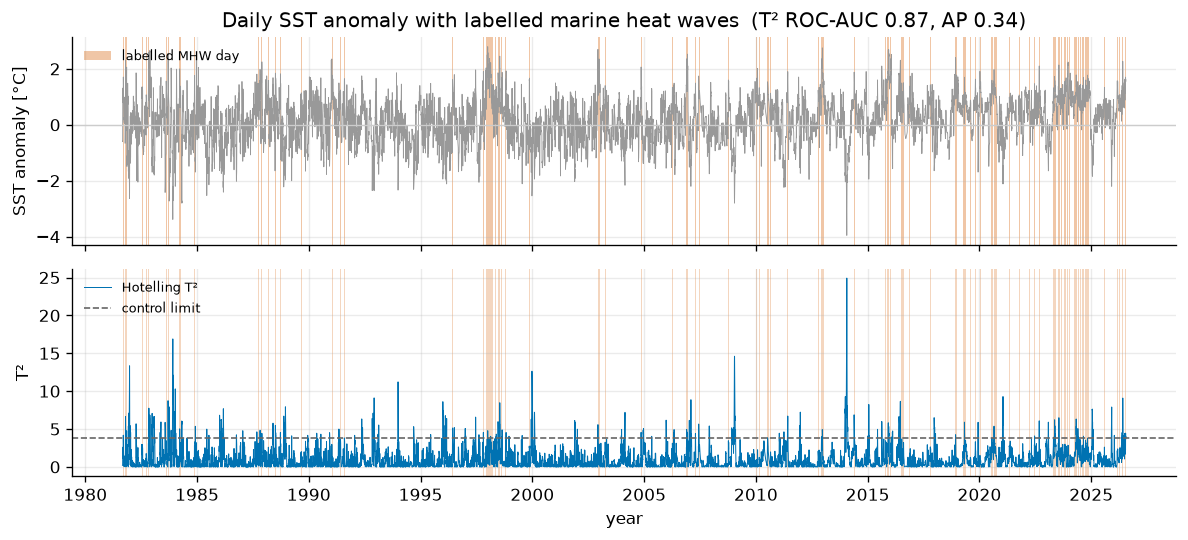

In [9]:
M = ed.build_mhw_labeled(channels=("sst","anomaly"), verbose=True)
mdates, MX, y = M["dates"], M["X"], M["label"]
ntr = int(0.5*len(y))
mdet = PCASubspaceDetector(k=1, alpha=0.05).fit(MX, n_train=ntr)
sm = mdet.score(MX)
auc, ap = roc_auc_score(y, sm["t2"]), average_precision_score(y, sm["t2"])
anom = MX[:,1]
fig, (a0,a1) = plt.subplots(2,1, figsize=(10,4.6), sharex=True)
a0.plot(mdates, anom, color="#999999", lw=0.5)
shade(a0, mdates, y, EVENT_C, 0.35, "labelled MHW day")
a0.axhline(0,color="#ccc",lw=0.8); a0.set_ylabel("SST anomaly [°C]")
a0.set_title(f"Daily SST anomaly with labelled marine heat waves  (T² ROC-AUC {auc:.2f}, AP {ap:.2f})")
a0.legend(loc="upper left", fontsize=8)
a1.plot(mdates, sm["t2"], color=FLAG_C, lw=0.6, label="Hotelling T²")
a1.axhline(mdet.t2_limit_, color=LIMIT_C, ls="--", lw=1.0, label="control limit")
shade(a1, mdates, y, EVENT_C, 0.25)
a1.set_ylabel("T²"); a1.set_xlabel("year"); a1.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

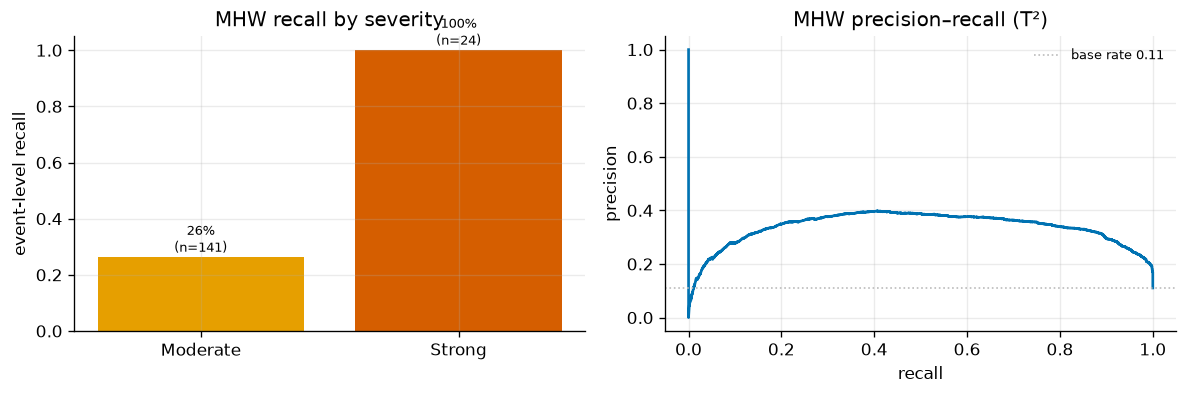

overall event-level recall: 0.37 (61/165 events)


In [10]:
# event-level recall by MHW severity + PR curve
fl = mdet.predict(MX, which="t2", rule="limit")
ev = M["events"]
def caught(row):
    mm=(mdates>=np.datetime64(row["start"]))&(mdates<=np.datetime64(row["end"])); return fl[mm].any()
ev = ev.assign(caught=ev.apply(caught, axis=1))
by_cat = ev.groupby("category")["caught"].agg(["mean","count"]).reindex(
    ["Moderate","Strong","Severe","Extreme"]).dropna()
fig,(a0,a1)=plt.subplots(1,2, figsize=(10,3.4))
a0.bar(by_cat.index, by_cat["mean"], color=[OI[1],OI[3],OI[4],OI[7]][:len(by_cat)])
for i,(m_,n_) in enumerate(zip(by_cat["mean"],by_cat["count"])):
    a0.text(i, m_+0.02, f"{m_:.0%}\n(n={int(n_)})", ha="center", fontsize=8)
a0.set_ylim(0,1.05); a0.set_ylabel("event-level recall"); a0.set_title("MHW recall by severity")
pr,rc,_=precision_recall_curve(y, sm["t2"])
a1.plot(rc,pr,color=FLAG_C,lw=1.6); a1.axhline(y.mean(),color="#bbb",ls=":",lw=1,label=f"base rate {y.mean():.2f}")
a1.set(xlabel="recall",ylabel="precision",title="MHW precision–recall (T²)"); a1.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"overall event-level recall: {ev['caught'].mean():.2f} ({int(ev['caught'].sum())}/{len(ev)} events)")

## Summary — which PC detector for which anomaly

| Anomaly | Best detector | Result |
|---|---|---|
| **Compound ENSO co-exceedance** (rare, level-defined, multivariate) | subspace **Hotelling T²** (`pca_subspace.py`) | ROC-AUC **0.96**, F1 ≈ **0.44** at the parametric limit (base rate 0.04) |
| **Marine heat waves** (daily, level-defined) | subspace **T²** | ROC-AUC **0.87**; recovers the strong/severe events; PR-tunable |
| **Structural / regime windows** (dynamics change) | EGADS **feature-clustering** (`egads_features` + `egads_pc_cluster`) | flags structurally-unusual windows — the intended §3.3 triage use |

**Faithful to the sources.** The subspace detector is Lakhina et al. (SIGCOMM
2004) normal/residual subspaces with Jackson–Mudholkar (1979) Q-limits and
Hotelling T²; the feature detector is EGADS §3.3 with the §4.1 threshold rules
and the Wang–Hyndman feature catalogue (EGADS ref [29]). Every threshold is fit
on the training span only. The honest finding — that level-invariant features
cannot see a co-exceedance, so the two PC methods address *different* anomaly
classes — is itself the EGADS thesis: no single model is best on all use-cases
(paper §6.3), which is why the framework combines several.